In [8]:
from scipy.optimize import minimize

import numpy as np
import torch
import os
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

from pointcloud.config_varients import caloclouds_3_S2P_withincell, caloclouds_3_S2P_hdbscan


from pointcloud.utils.metadata import Metadata
from pointcloud.utils import detector_map
from pointcloud.data.read_write import read_raw_regaxes, get_n_events
from pointcloud.data.conditioning import read_raw_regaxes_withcond

# imports specific to this evaluation
from pointcloud.evaluation.bin_standard_metrics import (
    conditioned_sample_model,
    get_caloclouds_models,
)
from pointcloud.evaluation.calculate_scale_factors import construct_dsf, get_path, DetectorScaleFactors


In [9]:
redo = True
models = {}
torch.set_default_dtype(torch.float32)

# static_dataset = "/data/dust/user/dayhallh/data/ILCsoftEvents/highGran_g40_p22_th90_ph90_en10-100.hdf5"
static_n_files = 10

angular_dataset = caloclouds_3_S2P_withincell.Configs().dataset_path
angular_n_files = caloclouds_3_S2P_withincell.Configs().n_dataset_files

try:
    if True:  # CC3 S2P withincell model
        config = caloclouds_3_S2P_withincell.Configs()
        config.device = 'cpu'
        config.cond_features = 4
        config.diffusion_pointwise_hidden_l1 = 32
        config.distillation = True
        config.cond_features_names = ["energy", "p_norm_local"]
        caloclouds_paths = ["/eos/user/m/mamozzan/CaloClouds-3/log_dir/CD_S2P_WithinCell_2026_06_05__14_20_48/ckpt_0.000000_10000000.pt"]
        showerflow_paths = ["/eos/user/m/mamozzan/point-cloud-diffusion-data/showerFlow/input_cc3_withincell/ShowerFlow_alt1_nb2_inputs1152921504606846975_fnorms_best.pth"]

        caloclouds = get_caloclouds_models(
            caloclouds_paths=caloclouds_paths, showerflow_paths=showerflow_paths,
            caloclouds_names=["CaloClouds3"], showerflow_names=["ShowerFlow_a1_fnorms_2"],
            config=config
        )

        train_dataset_meta = Metadata(caloclouds_3_S2P_withincell.Configs())
        meta_here = Metadata(caloclouds_3_S2P_withincell.Configs())

        meta_here.incident_rescale = 127
        meta_here.n_pts_rescale = train_dataset_meta.n_pts_rescale
        meta_here.vis_eng_rescale = 3.5

        meta_here.mean_cog[:] = [-4.06743696e-03, 0.321829, 1.10137465e+01]
        meta_here.std_cog[:] = [1.24559791, 0.95357278, 2.59475371]

        meta_here.log_incident_mean = train_dataset_meta.log_incident_mean
        meta_here.log_incident_std = train_dataset_meta.log_incident_std
        meta_here.found_attrs += ["log_incident_mean", "log_incident_std"]

        Xmean, Ymean, Zmean = -0.0074305227, -0.21205868, 12.359252
        Xstd, Ystd, Zstd = 22.4728036, 23.65837968, 5.305082

        meta_here.Xmax_global = 2*Ymean
        meta_here.Xmin_global = 2*(2*Ystd - Ymean)
        meta_here.Zmax_global = 2*Xmean
        meta_here.Zmin_global = 2*(2*Xstd - Xmean)

        print('\n~~~~~~~~\n')
        print(repr(meta_here))
        print('\n~~~~~~~~\n')

        caloclouds["CaloClouds3-ShowerFlow_a1_fnorms_2"][2].metadata = meta_here
        models.update(caloclouds)

except FileNotFoundError as e:
    print("CaloClouds models not found")
    print(e)


config = caloclouds_3_S2P_withincell.Configs()
config.device = 'cpu'
config.dataset_path_in_storage = False
config._dataset_path = angular_dataset
config.n_dataset_files = angular_n_files
config.dataset_tag = "p22_th45-135_ph79-109_en5-130"
config.metadata_folder = "p22_th90_ph90_en10-100W"

model_name = "CaloClouds3-ShowerFlow_a1_fnorms_2"
save_name = get_path(config, model_name)
g4_gun = np.array([40, 50, 0])
n_events = 1_000
if os.path.exists(save_name) and not redo:
    dsf1 = DetectorScaleFactors.load(save_name)
    print("Loaded")
else:
    print("Constructing dsf1")
    model_gun = np.array([40, 50, 0])
    dsf1 = construct_dsf(config, model_name, models[model_name][2], models[model_name][0], models[model_name][1], model_gun_pos=model_gun, g4_gun_pos=g4_gun, max_g4_events=n_events)
    dsf1.save(save_name)

model_name_2 = 'CaloClouds3-ShowerFlow_a1_fnorms_2'
save_name_2 = save_name  # same model — reuse dsf1
dsf_2 = dsf1


/eos/user/m/mamozzan/CaloClouds-3/log_dir/CD_S2P_WithinCell_2026_06_05__14_20_48/ckpt_0.000000_10000000.pt
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-data /eos/user/m/mamozzan/point-cloud-diffusion-data
mamozzan
/eos/user/m/mamozzan/point-cloud-diffusion-d

100%|██████████| 1000/1000 [00:01<00:00, 543.26it/s]



Done


In [10]:

def plot_sample(dsf, model_name, n_samples, sample_n_coeff, sample_e_coeff=None, fake_n_coeff=None):
    mean_sq_n, mean_sq_e = dsf.divergance(n_samples, sample_n_coeff, sample_e_coeff, fake_n_coeff)
    cond_energies = dsf.cond["energy"][dsf.cond_idxs]
    g4_n = dsf.g4_detector_n[dsf.cond_idxs]
    g4_e = dsf.g4_detector_e[dsf.cond_idxs]
    
    from matplotlib import pyplot as plt
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    scatter_args = dict(alpha=0.5)
    axs[0].set_ylabel("Active cells")
    axs[1].set_ylabel("Detected energy")
    axs[0].scatter(cond_energies, g4_n, label="g4", **scatter_args)
    axs[0].scatter(cond_energies, dsf.model_n, label=model_name, **scatter_args)
    axs[1].scatter(cond_energies, g4_e, label="g4", **scatter_args)
    axs[1].scatter(cond_energies, dsf.model_e, label=model_name, **scatter_args)
    
    for ax in axs:
        ax.legend()
        ax.set_xlabel("Conditioning energy")
    axs[0].set_title(f"Mean squared error = {mean_sq_n}")
    axs[1].set_title(f"Mean squared error = {mean_sq_e}")

100%|██████████| 1000/1000 [00:02<00:00, 453.01it/s]


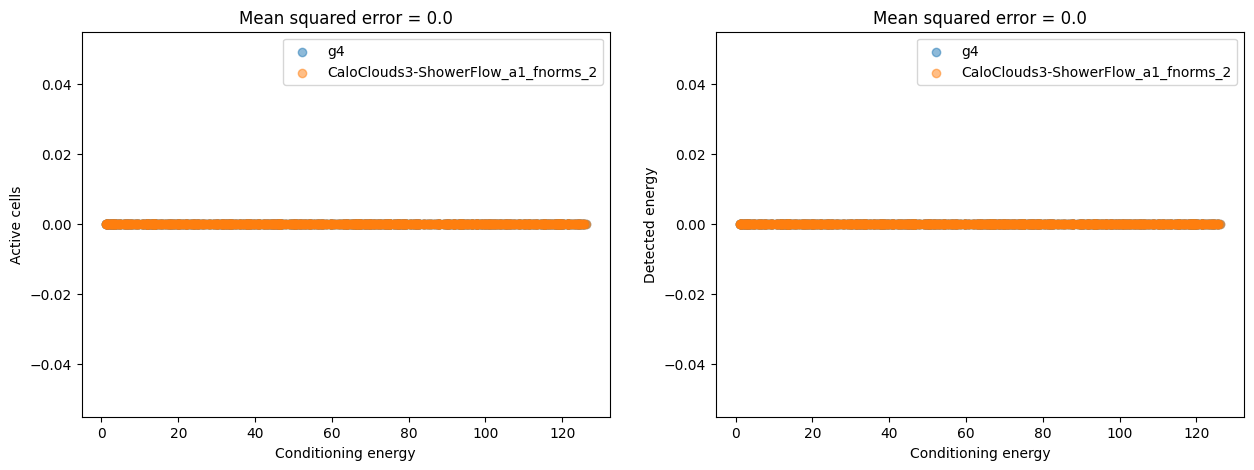

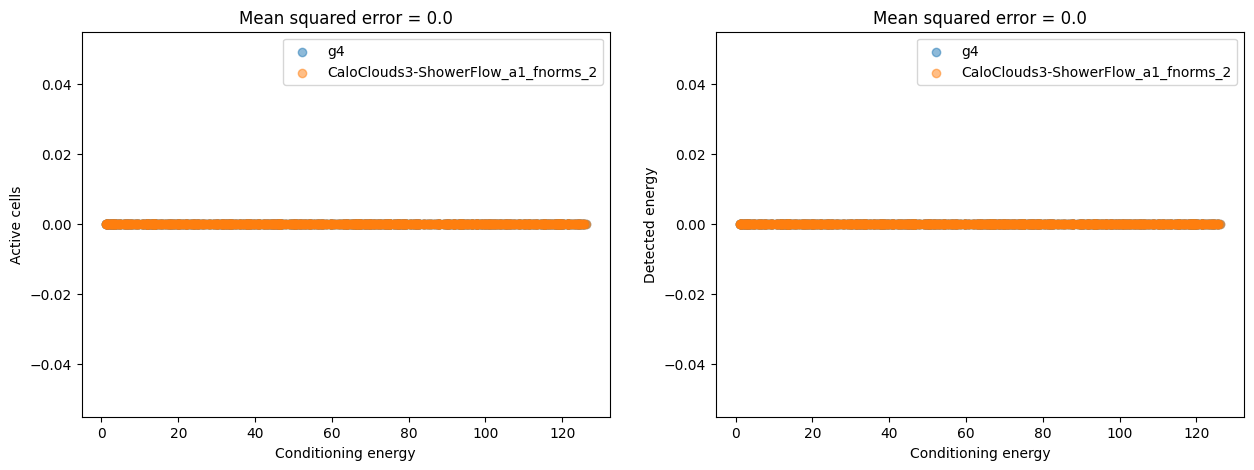

In [11]:

n_samples = dsf1.n_retained
sample_n_coeff = np.zeros(4)
sample_n_coeff[-2] = 1.
sample_e_coeff = np.array([1., 0.])
sample_e_coeff_2 = np.array([1., 0.])
plot_sample(dsf1, model_name, n_samples, sample_n_coeff, sample_e_coeff)
plot_sample(dsf_2, model_name_2, n_samples, sample_n_coeff, sample_e_coeff_2)

100%|██████████| 1000/1000 [00:01<00:00, 538.22it/s]


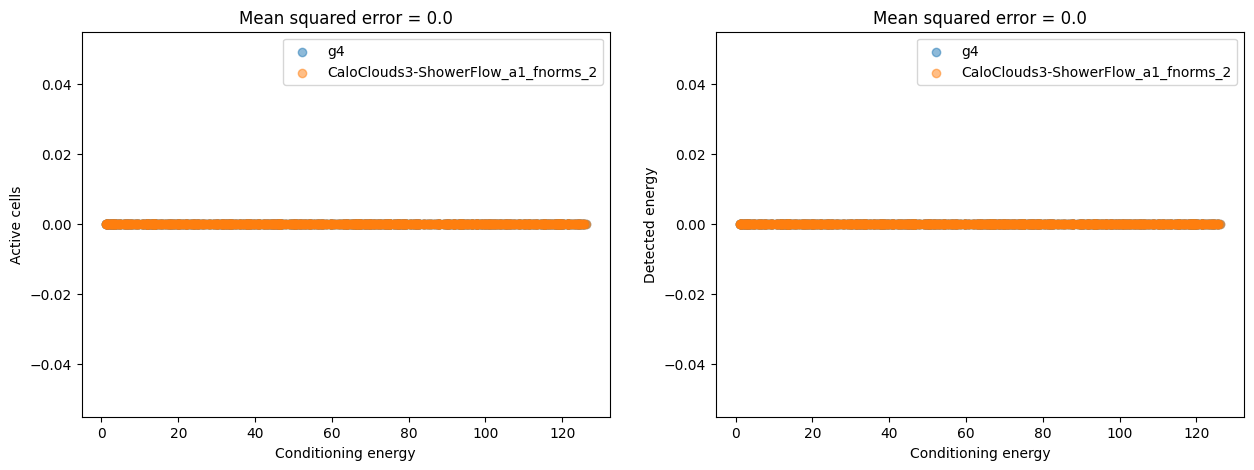

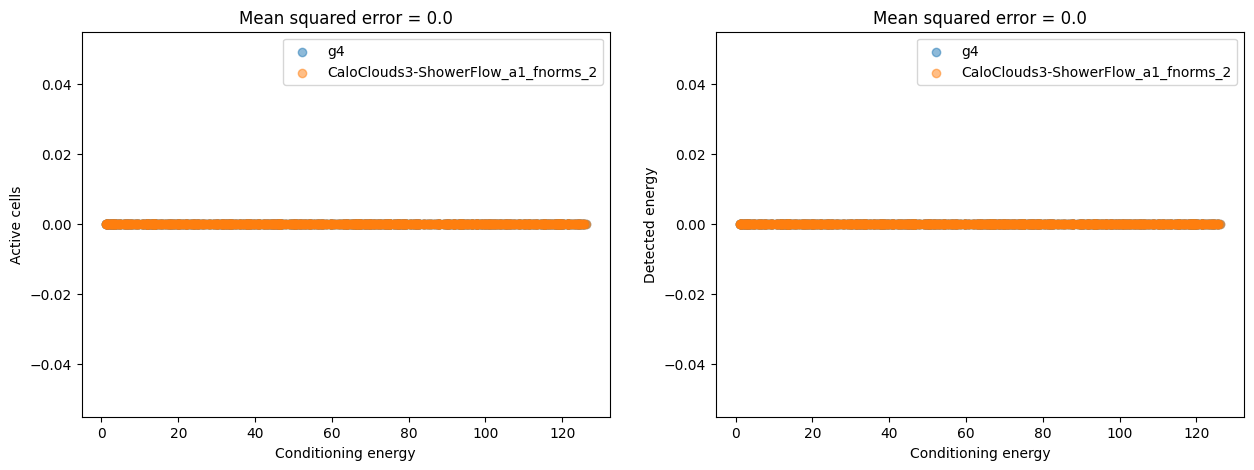

In [12]:

n_samples = dsf1.n_retained
sample_n_coeff = np.zeros(4)
sample_n_coeff[-2] = 1.
sample_e_coeff = np.array([5.486e-01, 0.])
sample_e_coeff_2 = np.array([9.768e-01, 0.])
plot_sample(dsf1, model_name, n_samples, sample_n_coeff, sample_e_coeff)
plot_sample(dsf_2, model_name_2, n_samples, sample_n_coeff, sample_e_coeff_2)

dict_keys(['g4_events', 'cond_energy', 'cond_points', 'cond_p_norm_local', 'g4_projected', 'g4_projected_postMip', 'raw_model_events', 'model_events', 'model_projected', 'model_projected_postMip'])


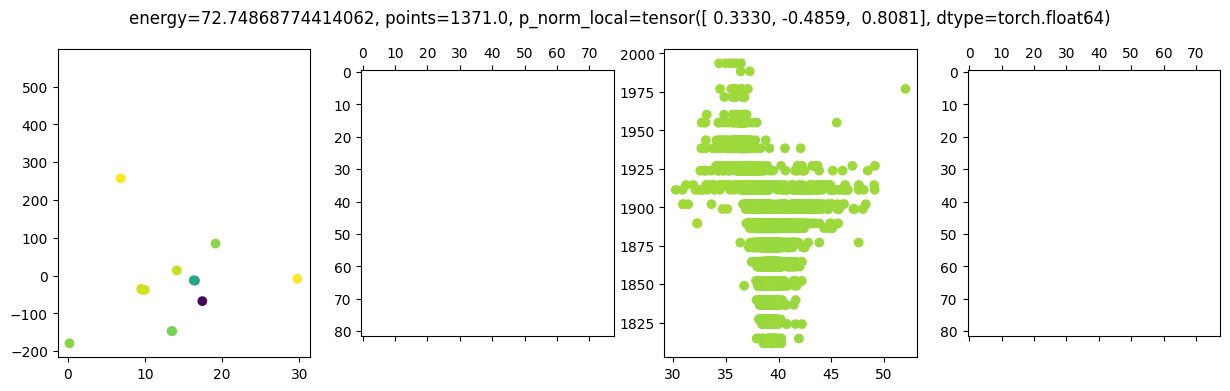

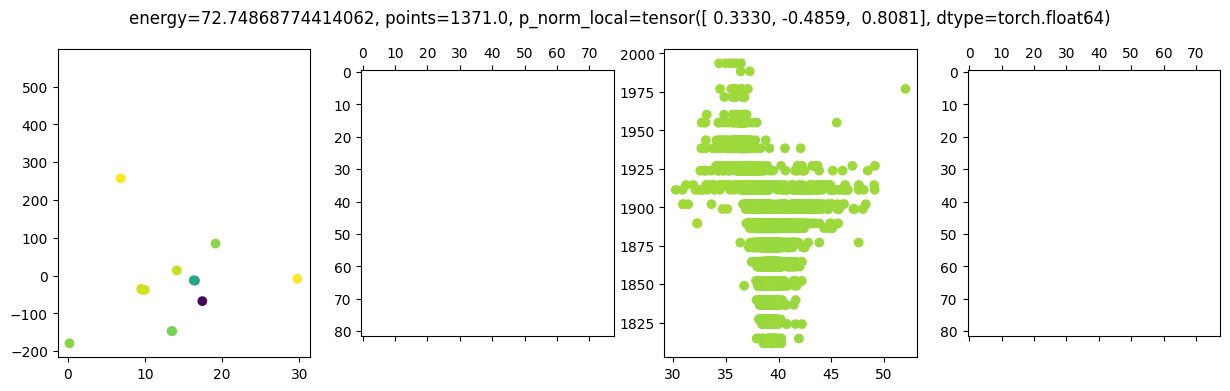

In [13]:


print(dsf1.retain_dict.keys())

for dsf in [dsf1, dsf_2]:
    i = 0
    l = 15
    x = 0
    y = 2
    c = 1
    fig, axarr = plt.subplots(1, 4, figsize=(15, 4))
    fig.suptitle(f"energy={dsf.retain_dict['cond_energy'][i][0]}, points={dsf.retain_dict['cond_points'][i][0]}, p_norm_local={dsf.retain_dict['cond_p_norm_local'][i][:]}")
    vmin, vmax = 0.0001, 1
    vmin2, vmax2 = 0.1, 100
    g4_evt = dsf.retain_dict['g4_events'][i]
    g4_evt = g4_evt[g4_evt[:, 3]>0]
    md_evt = dsf.retain_dict['raw_model_events'][i]
    md_evt = md_evt[md_evt[:, 3]>0]
    axarr[0].scatter(g4_evt[:, x], g4_evt[:, y], c=g4_evt[:, c], norm=LogNorm(vmin=vmin2, vmax=vmax2))
    axarr[1].matshow(dsf.retain_dict['g4_projected_postMip'][i][l], norm=LogNorm(vmin=vmin, vmax=vmax))
    axarr[2].scatter(md_evt[:, x], md_evt[:, y], c=md_evt[:, c], norm=LogNorm(vmin=vmin2, vmax=vmax2))
    axarr[3].matshow(dsf.retain_dict['model_projected_postMip'][i][l], norm=LogNorm(vmin=vmin, vmax=vmax))

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2909870/1363433346.py:33: SyntaxWarning: invalid escape sequence '\m'
  l = f"{label}, $\mu$={mean[i]:.4}, $\sigma$={std[i]:.4}"
/tmp/ipykernel_2909870/1363433346.py:33: SyntaxWarning: invalid escape sequence '\s'
  l = f"{label}, $\mu$={mean[i]:.4}, $\sigma$={std[i]:.4}"
/tmp/ipykernel_2909870/1363433346.py:24: RuntimeWarning: invalid value encountered in divide
  after_cogs.append(denominator/numerator[:, None])


ValueError: autodetected range of [nan, nan] is not finite

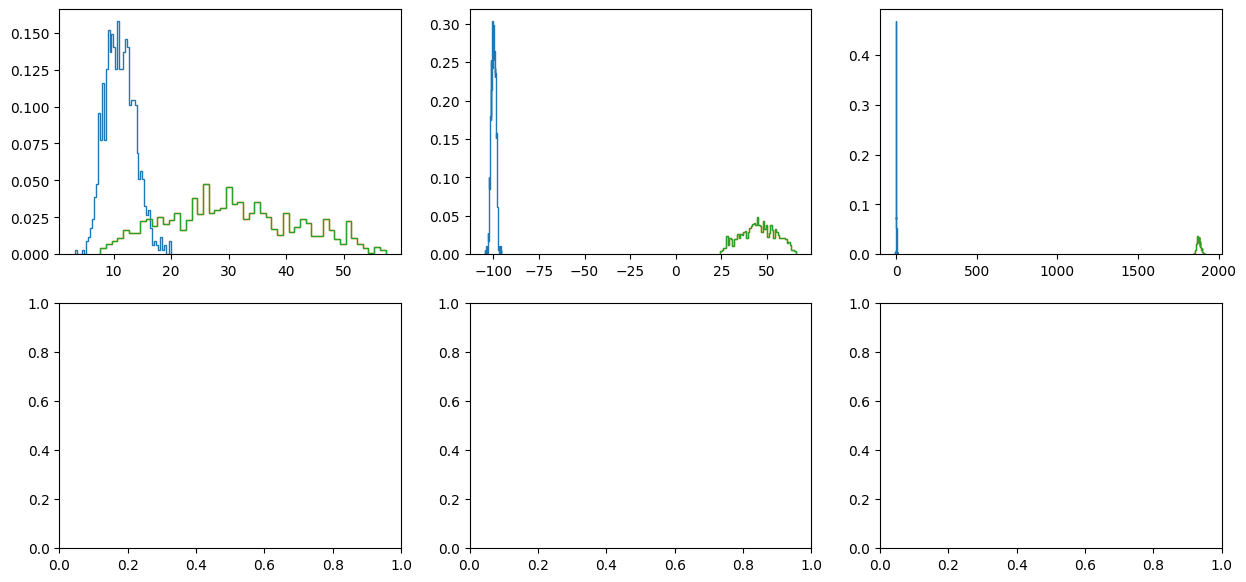

In [15]:
labels = ["g4", "CC2", "CC3"]
before = [dsf1.retain_dict['g4_events']] + [dsf.retain_dict['model_events'] for dsf in [dsf1, dsf_2]]
after =  [dsf1.retain_dict['g4_projected']] + [dsf.retain_dict['model_projected'] for dsf in [dsf1, dsf_2]]
before_cogs = []
after_cogs = []
after_x_pos = [np.linspace(0, 1, len(l))[:, None] for l in after[0][0]]
after_y_pos = [np.linspace(0, 1, len(l[0])) for l in after[0][0]]
after_z_pos = np.linspace(0, 1, len(after[0][0]))

for i in range(3):
    b = np.array(before[i])
    m = (b[:, :, 3]>0)[:, :, None]
    cogs = np.sum((m*b[:, :, :3]*b[:, :, [3]]), axis=1)/np.sum(m*b[:, :, [3]], axis=1)
    before_cogs.append(cogs)
    denominator = np.zeros_like(cogs)
    numerator = np.zeros(len(cogs))
    a = after[i]
    for e, event in enumerate(a):
        for l, layer in enumerate(event):
            denominator[e, 0] += np.sum(after_x_pos[l]*layer)
            denominator[e, 1] += np.sum(after_y_pos[l]*layer)
            denominator[e, 2] += np.sum(after_z_pos[l]*layer)
            numerator[e] += np.sum(layer)
    after_cogs.append(denominator/numerator[:, None])
        
fig, axarr = plt.subplots(2, 3, figsize=(15, 7))

for axline, cogs in [(axarr[0], before_cogs), (axarr[1], after_cogs)]:
    for label, cog in zip(labels, cogs):
        mean = np.mean(cog, axis=0)
        std = np.std(cog, axis=0)
        for i in range(3):
            l = f"{label}, $\mu$={mean[i]:.4}, $\sigma$={std[i]:.4}"
            axline[i].hist(cog[:, i], label=l, histtype='step', bins=50, density=True)

for ax in axarr.flatten():
    ax.legend()


100%|██████████| 500/500 [00:05<00:00, 91.78it/s]


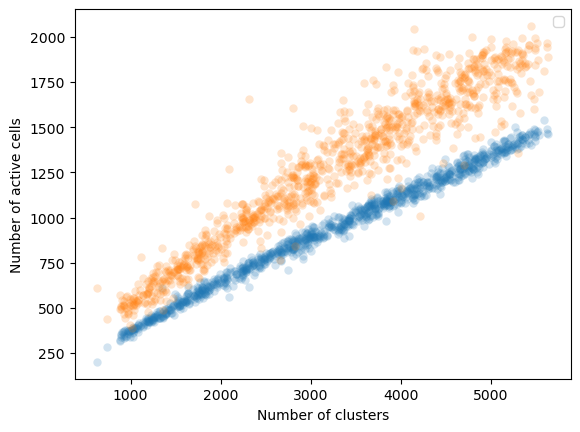

In [ ]:

points = dsf1.cond['points']

unit = np.zeros(2)
unit[0] = 1.
batch_size = 500
total_events = len(dsf1.cond['energy'])
all_model_n, all_model_e = np.empty(total_events), np.empty(total_events)
for batch_start in range(0, total_events, batch_size):
    batch_end = min(batch_size+batch_start, total_events)
    batch_idxs = list(range(batch_start, batch_end))
    n, e = dsf1.model_events(batch_idxs, unit, None)
    all_model_n[batch_start:batch_end] = n
    all_model_e[batch_start:batch_end] = e

from matplotlib import pyplot as plt
plt.scatter(points, dsf1.g4_detector_n, alpha=0.2, lw=0)
plt.scatter(points, all_model_n, alpha=0.2, lw=0)
plt.legend()
plt.xlabel("Number of clusters")
plt.ylabel("Number of active cells")
xs = np.linspace(500, 5500)


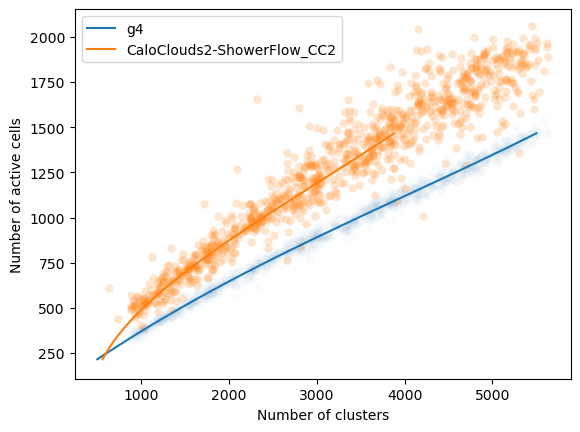

In [ ]:

from matplotlib import pyplot as plt
xs = np.linspace(500, 5500)
plt.scatter(points, dsf1.g4_detector_n, alpha=0.02, lw=0)
plt.legend()
plt.xlabel("Number of clusters")
plt.ylabel("Number of active cells")
plt.scatter(points, all_model_n, alpha=0.2, lw=0)
if hasattr(dsf1, "real_coeff") and not redo:
    real_coeff = dsf1.real_coeff
    fake_coeff = dsf1.fake_coeff
    print("Previously calculated")
else:
   
    real_coeff = np.polyfit(points.flatten(), dsf1.g4_detector_n, 3)
    fake_coeff = np.polyfit(all_model_n, points.flatten(), 3)
    dsf1.real_coeff = real_coeff
    dsf1.fake_coeff = fake_coeff
    dsf1.save(save_name)
    
    
ys = np.polyval(real_coeff, xs)
plt.plot(xs, np.polyval(real_coeff, xs), label="g4")
plt.plot(np.polyval(fake_coeff, ys), ys, label=model_name)
plt.legend()

In [ ]:
fake_coeff, real_coeff

(array([-7.49377548e-07,  2.69954466e-03, -2.35388812e-03,  4.42644615e+02]),
 array([ 2.66430185e-09, -3.19668816e-05,  3.53275061e-01,  4.65393214e+01]))

100%|██████████| 100/100 [00:01<00:00, 93.66it/s]


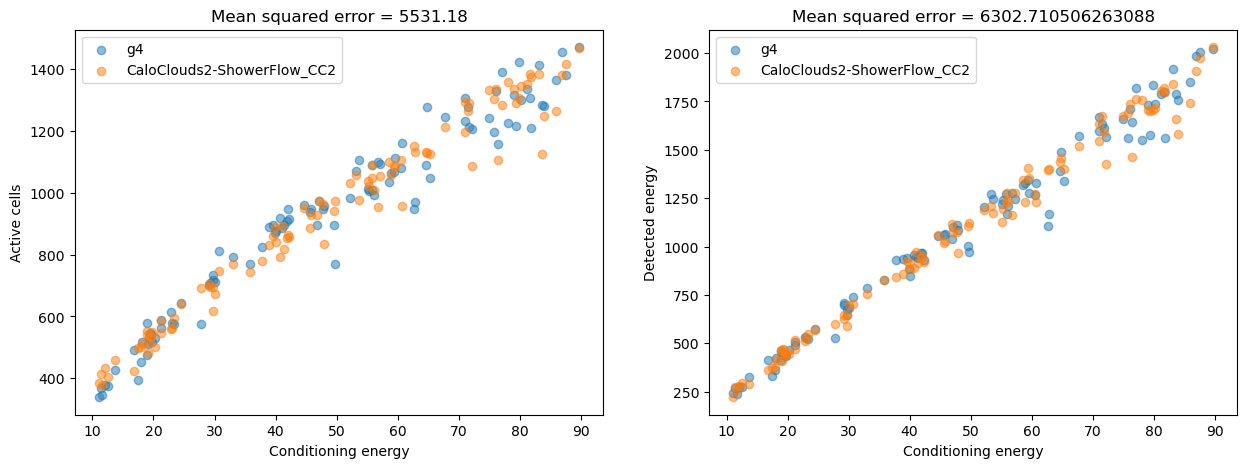

In [ ]:
n_samples=100
plot_sample(dsf1, model_name, n_samples, real_coeff, None, fake_coeff)

100%|██████████| 500/500 [00:08<00:00, 62.21it/s]


Text(0, 0.5, 'Number of active cells')

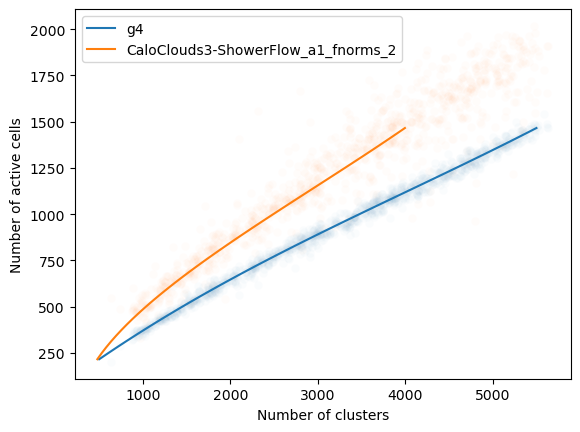

In [ ]:

points_2 = dsf_2.cond['points']

if hasattr(dsf_2, "real_coeff") and not redo:
    real_coeff_2 = dsf_2.real_coeff
    fake_coeff_2 = dsf_2.fake_coeff
    print("Previously calculated")
else:
    unit = np.zeros(2)
    unit[0] = 1.
    batch_size = 500
    total_events_2 = len(dsf_2.cond['energy'])
    all_model_n_2, all_model_e_2 = np.empty(total_events_2), np.empty(total_events_2)
    for batch_start in range(0, total_events_2, batch_size):
        batch_end = min(batch_size+batch_start, total_events_2)
        batch_idxs = list(range(batch_start, batch_end))
        n, e = dsf_2.model_events(batch_idxs, unit, None)
        all_model_n_2[batch_start:batch_end] = n
        all_model_e_2[batch_start:batch_end] = e
    real_coeff_2 = np.polyfit(points_2.flatten(), dsf_2.g4_detector_n, 3)
    fake_coeff_2 = np.polyfit(all_model_n_2, points_2.flatten(), 3)
    dsf_2.real_coeff = real_coeff_2
    dsf_2.fake_coeff = fake_coeff_2
    dsf_2.save(save_name_2)

from matplotlib import pyplot as plt
plt.scatter(points_2, dsf_2.g4_detector_n, alpha=0.02, lw=0)
xs = np.linspace(500, 5500)
ys = np.polyval(real_coeff_2, xs)
plt.plot(xs, np.polyval(real_coeff_2, xs), label="g4")
plt.scatter(points_2, all_model_n_2, alpha=0.02, lw=0)
plt.plot(np.polyval(fake_coeff_2, ys), ys, label=model_name_2)
plt.legend()
plt.xlabel("Number of clusters")
plt.ylabel("Number of active cells")

In [ ]:

if hasattr(dsf1, "final_e_coeff") and not redo:
    sample_e_coeff_1 = dsf1.final_e_coeff
    print(f"Already done {sample_e_coeff_1}")
else:
    def to_minimise_1b(coeff_e):
        n_samples = 100
        sample_e_coeff = np.zeros(2, dtype=float)
        sample_e_coeff[0] = coeff_e
        mean_sq_n, mean_sq_e = dsf1.divergance(n_samples, real_coeff, sample_e_coeff, fake_coeff)
        return mean_sq_e
    res_e_coeff_1 = minimize(to_minimise_1b, x0=1., method='Powell', bounds=[(0.5, 1.5),], options={'disp': True, 'maxiter':1000, 'xtol':1e-6, 'ftol':1e-4})
    print(res_e_coeff_1)
    sample_e_coeff_1 = np.zeros(4)
    sample_e_coeff_1[-2] = res_e_coeff_1.x
    dsf1.final_e_coeff = sample_e_coeff_1
    dsf1.save(save_name)



100%|██████████| 100/100 [00:01<00:00, 94.56it/s]


Optimization terminated successfully.
         Current function value: 6016.278126
         Iterations: 3
         Function evaluations: 71
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 6016.278125741871
       x: [ 9.981e-01]
     nit: 3
   direc: [[ 1.000e+00]]
    nfev: 71


100%|██████████| 100/100 [00:01<00:00, 93.04it/s]


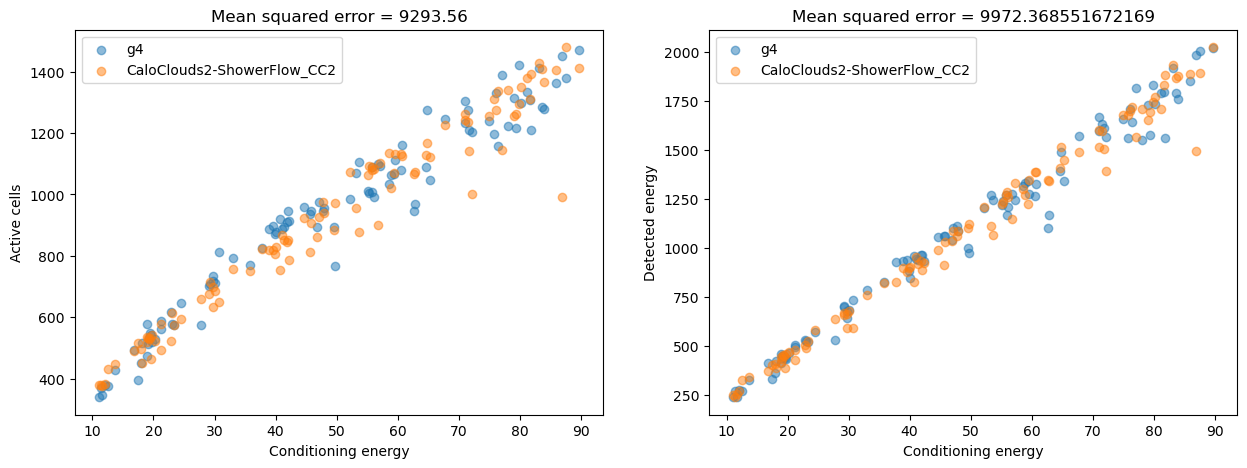

In [ ]:
n_samples=100
plot_sample(dsf1, model_name, n_samples, real_coeff, sample_e_coeff_1, fake_coeff)

100%|██████████| 100/100 [00:01<00:00, 61.49it/s]


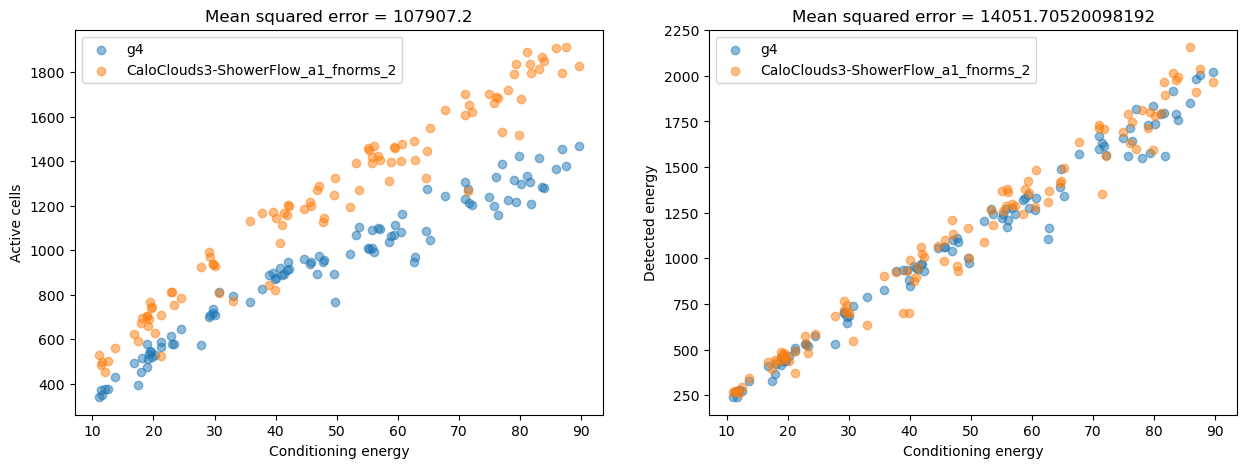

In [ ]:

n_samples = 100
sample_n_coeff = np.zeros(4)
sample_n_coeff[-2] = 1.
plot_sample(dsf_2, model_name_2, n_samples, sample_n_coeff)

In [ ]:


def to_minimise_2a(coeff_n):
    n_samples = 500
    sample_n_coeff = np.zeros(2, dtype=float)
    sample_n_coeff[:] = coeff_n
    mean_sq_n, mean_sq_e = dsf_2.divergance(n_samples, sample_n_coeff)
    idxs = dsf_2.cond_idxs
    g4_n = dsf_2.g4_detector_n[idxs]
    model_n = dsf_2.model_n
    weighted_distance = np.sum(np.abs(g4_n-model_n)/(g4_n+model_n))
    return weighted_distance


    

if hasattr(dsf_2, "final_n_coeff") and not redo:
    sample_n_coeff = dsf_2.final_n_coeff
    print(f"Already done {sample_n_coeff}")
else:
    x0 = np.zeros(2)
    x0[0] = 1.
    res_n_coeff_2 = minimize(to_minimise_2a, x0=1., method='Powell', bounds=[(0.5, 1.5),], options={'disp': True, 'maxiter':1000, 'xtol':1e-6, 'ftol':1.})
    print(res_n_coeff_2)
    sample_n_coeff = np.zeros(2)
    sample_n_coeff[0] = res_n_coeff_2.x
    dsf_2.final_n_coeff = sample_n_coeff
    dsf_2.save(save_name_2)

100%|██████████| 500/500 [00:08<00:00, 61.48it/s]


Optimization terminated successfully.
         Current function value: 17.838103
         Iterations: 2
         Function evaluations: 83
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 17.838102526981007
       x: [ 6.479e-01]
     nit: 2
   direc: [[-1.564e-02]]
    nfev: 83


100%|██████████| 100/100 [00:01<00:00, 63.15it/s]


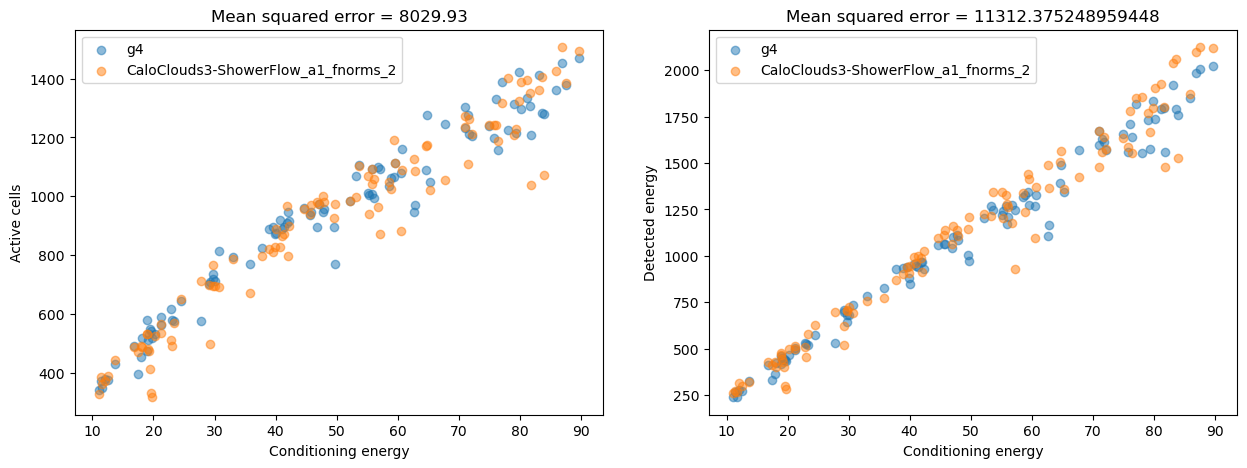

In [ ]:
n_samples = 100

plot_sample(dsf_2, model_name_2, n_samples, sample_n_coeff)

In [ ]:


def to_minimise_2b(coeff_e):
    n_samples = 500
    sample_n_coeff = np.zeros(2, dtype=float)
    sample_n_coeff[0] = res_n_coeff_2.x
    sample_e_coeff = np.zeros(2, dtype=float)
    sample_e_coeff[0] = coeff_e
    mean_sq_n, mean_sq_e = dsf_2.divergance(n_samples, sample_n_coeff, sample_e_coeff)
    idxs = dsf_2.cond_idxs
    g4_e = dsf_2.g4_detector_e[idxs]
    model_e = dsf_2.model_e
    weighted_distance = np.sum((g4_e-model_e)**2/(g4_e+model_e)**2)
    return weighted_distance


if hasattr(dsf_2, "final_e_coeff") and not redo:
    sample_e_coeff = dsf_2.final_e_coeff
    print(f"Already done {sample_e_coeff}")
else:
    x0 = np.zeros(2, dtype=float)
    res_e_coeff_2 = minimize(to_minimise_2b, x0=1., method='Powell', bounds=[(0.5, 1.5),], options={'disp': True, 'maxiter':1000, 'xtol':1e-6, 'ftol':1e-4})
    print(res_e_coeff_2)
    sample_e_coeff = np.zeros(2)
    sample_e_coeff[0] = res_e_coeff_2.x
    dsf_2.final_e_coeff = sample_e_coeff
    dsf_2.save(save_name_2)



100%|██████████| 500/500 [00:07<00:00, 63.76it/s]


Optimization terminated successfully.
         Current function value: 1.063852
         Iterations: 4
         Function evaluations: 102
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 1.063851990854614
       x: [ 9.758e-01]
     nit: 4
   direc: [[ 1.000e+00]]
    nfev: 102


100%|██████████| 100/100 [00:01<00:00, 61.73it/s]


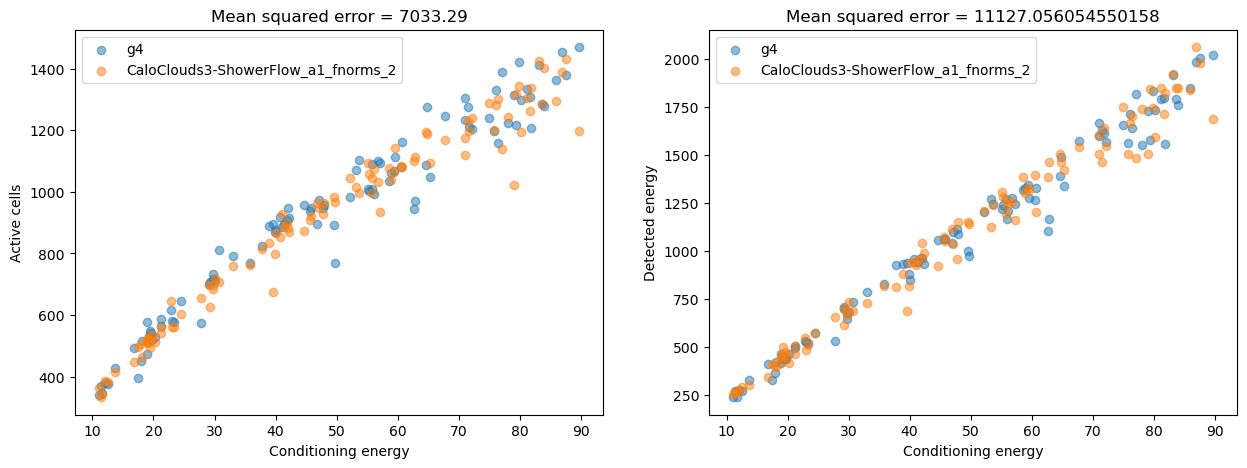

In [ ]:
n_samples = 100
plot_sample(dsf_2, model_name_2, n_samples, sample_n_coeff, sample_e_coeff)

In [ ]:
loaded = dict(np.load(save_name, allow_pickle=True))
loaded["real_coeff"] = real_coeff
loaded["fake_coeff"] = fake_coeff
loaded["final_e_coeff"] = sample_e_coeff_1
np.savez(save_name, **loaded)


In [ ]:
loaded = dict(np.load(save_name_2, allow_pickle=True))
loaded["final_n_coeff"] = sample_n_coeff
loaded["final_e_coeff"] = sample_e_coeff
np.savez(save_name_2, **loaded)

In [ ]:
real_coeff

array([ 2.66430185e-09, -3.19668816e-05,  3.53275061e-01,  4.65393214e+01])

In [ ]:
fake_coeff


array([-7.49377548e-07,  2.69954466e-03, -2.35388812e-03,  4.42644615e+02])

In [ ]:




model_name_2


'CaloClouds3-ShowerFlow_a1_fnorms_2'

In [ ]:
sample_e_coeff_1

array([0.        , 0.        , 0.99809405, 0.        ])

In [ ]:
sample_e_coeff

array([0.97583678, 0.        ])

In [ ]:
sample_n_coeff

array([0.64789054, 0.        ])

In [ ]:
save_name, save_name_2

('/data/dust/user/dayhallh/point-cloud-diffusion-logs/binned_metrics/CaloClouds2-ShowerFlow_CC2_p22_th90_ph90_en10-100_scaleFactor.npz',
 '/data/dust/user/dayhallh/point-cloud-diffusion-logs/binned_metrics/CaloClouds3-ShowerFlow_a1_fnorms_2_p22_th90_ph90_en10-100_scaleFactor.npz')

In [ ]:
sample_e_coeff